# 04 - Training mit Collector-Daten

Training des PV-Modulleistungs-Modells mit direkten Sensordaten.

- **Target**: `pv_dc_kwh` – DC-Eingangsleistung der Module (stündlich)
- **Daten**: Collector-DB (7 Tage, 5-Min-Intervall → stündlich aggregiert)
- **Features**: Open-Meteo Wetter + Zeitfeatures + Lag/Rolling

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.data.weather_connector import get_historical
from src.features.feature_engineering import (
    load_collector_data, build_hourly_from_collector,
    merge_weather, build_training_from_collector,
    FEATURE_COLS, TARGET_COL,
)
from src.models.pv_forecast import PVForecastModel
from src.config import PV_SPECS

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

DB_PATH = Path("../data/optimizepv.db")
print(f"Target: {TARGET_COL}")
print(f"PV Specs: Module {PV_SPECS['module_peak_kw']}kWp, WR {PV_SPECS['inverter_max_kw']}kW, Bat {PV_SPECS['battery_max_charge_kw']}kW")

Target: pv_dc_kwh
PV Specs: Module 13.4kWp, WR 10.0kW, Bat 5.0kW


## 1. Daten laden & Exploration

Rohdaten: 2046 Einträge (2026-05-12 bis 2026-05-19)
Stündlich: 170 Stunden


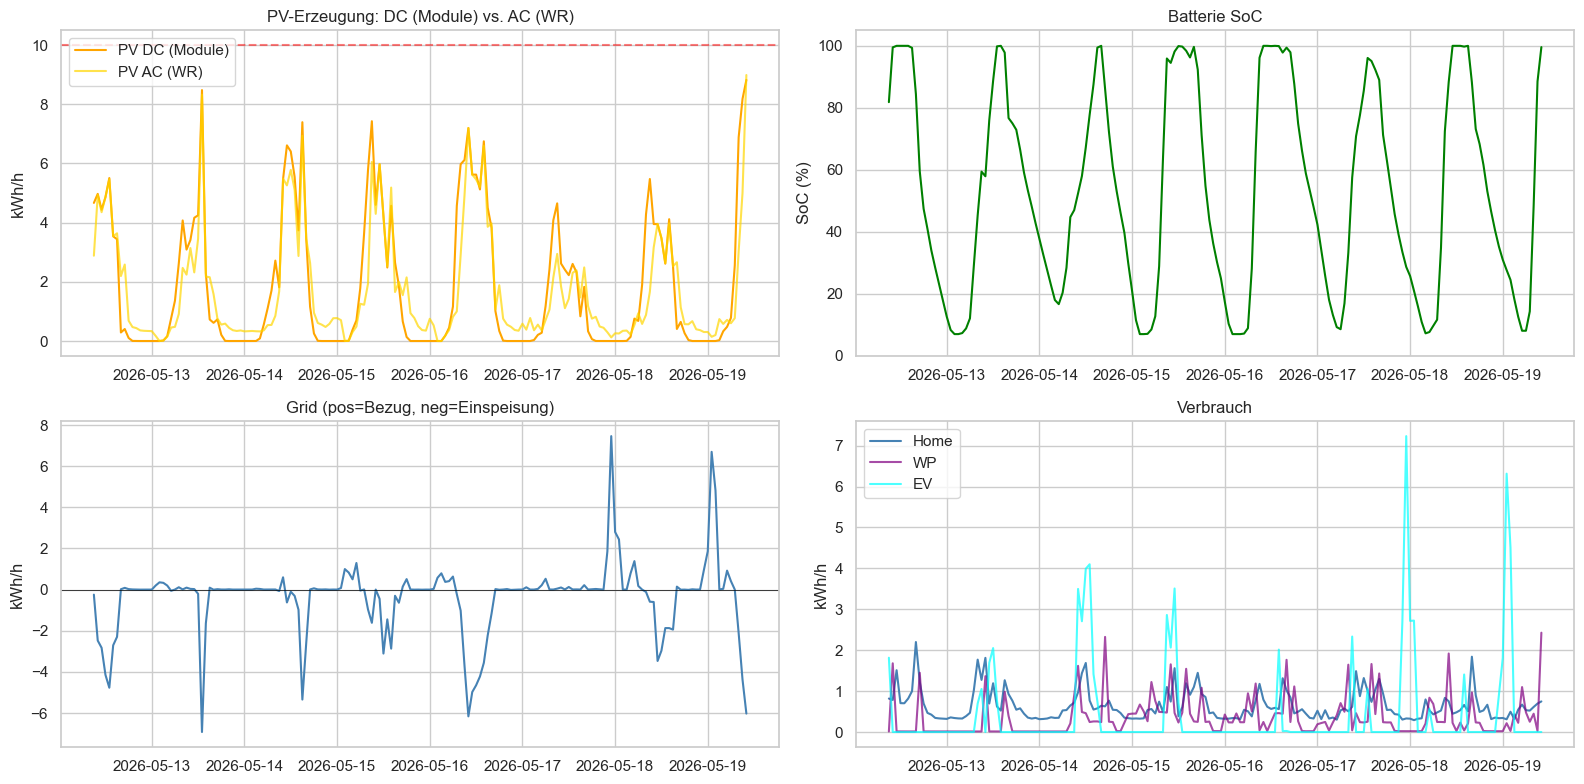


=== Anlagen-Analyse (7 Tage) ===
  PV DC gesamt: 314.0 kWh
  PV AC gesamt: 298.7 kWh
  WR-Clipping: 0 Stunden (>9.5kW)
  Clipping-Verlust: 64.4 kWh (20.5% des DC-Ertrags)
  Einspeisung: 107.7 kWh
  Batterie voll (>98%): 27 von 170 Stunden (16%)


In [2]:
# Rohdaten laden
raw = load_collector_data(db_path=DB_PATH)
print(f"Rohdaten: {len(raw)} Einträge ({raw['timestamp'].min().date()} bis {raw['timestamp'].max().date()})")

# Stündliche Aggregation
hourly = build_hourly_from_collector(raw)
print(f"Stündlich: {len(hourly)} Stunden")

# Übersicht
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0, 0].plot(hourly["timestamp"], hourly["pv_dc_kwh"], label="PV DC (Module)", color="orange")
axes[0, 0].plot(hourly["timestamp"], hourly["pv_kwh"], label="PV AC (WR)", color="gold", alpha=0.7)
axes[0, 0].set_ylabel("kWh/h")
axes[0, 0].set_title("PV-Erzeugung: DC (Module) vs. AC (WR)")
axes[0, 0].legend()
axes[0, 0].axhline(PV_SPECS["inverter_max_kw"], color="red", linestyle="--", alpha=0.5, label=f"WR-Limit {PV_SPECS['inverter_max_kw']}kW")

axes[0, 1].plot(hourly["timestamp"], hourly["battery_soc"], color="green")
axes[0, 1].set_ylabel("SoC (%)")
axes[0, 1].set_title("Batterie SoC")
axes[0, 1].set_ylim(0, 105)

axes[1, 0].plot(hourly["timestamp"], hourly["grid_kwh"], color="steelblue")
axes[1, 0].axhline(0, color="black", linewidth=0.5)
axes[1, 0].set_ylabel("kWh/h")
axes[1, 0].set_title("Grid (pos=Bezug, neg=Einspeisung)")

axes[1, 1].plot(hourly["timestamp"], hourly["home_kwh"], label="Home", color="steelblue")
axes[1, 1].plot(hourly["timestamp"], hourly["wp_kwh"], label="WP", color="purple", alpha=0.7)
axes[1, 1].plot(hourly["timestamp"], hourly["ev_kwh"], label="EV", color="cyan", alpha=0.7)
axes[1, 1].set_ylabel("kWh/h")
axes[1, 1].set_title("Verbrauch")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Anlagen-Statistiken
print(f"\n=== Anlagen-Analyse (7 Tage) ===")
wr_clipping_hours = (hourly["pv_kwh"] >= PV_SPECS["inverter_max_kw"] * 0.95).sum()
dc_gt_ac = (hourly["pv_dc_kwh"] - hourly["pv_kwh"]).clip(lower=0)
clipping_loss = dc_gt_ac.sum()
total_dc = hourly["pv_dc_kwh"].sum()
total_ac = hourly["pv_kwh"].sum()
total_export = hourly["grid_kwh"].clip(upper=0).sum()  # neg = export
bat_full_hours = (hourly["battery_soc"] >= 98).sum()

print(f"  PV DC gesamt: {total_dc:.1f} kWh")
print(f"  PV AC gesamt: {total_ac:.1f} kWh")
print(f"  WR-Clipping: {wr_clipping_hours} Stunden (>{PV_SPECS['inverter_max_kw']*0.95:.1f}kW)")
print(f"  Clipping-Verlust: {clipping_loss:.1f} kWh ({clipping_loss/total_dc*100:.1f}% des DC-Ertrags)")
print(f"  Einspeisung: {abs(total_export):.1f} kWh")
print(f"  Batterie voll (>98%): {bat_full_hours} von {len(hourly)} Stunden ({bat_full_hours/len(hourly)*100:.0f}%)")

## 2. Trainingsdatensatz erstellen

Wetter: 168 Stunden

Trainingsdatensatz: 133 Zeilen, 53 Spalten
Zeitraum: 2026-05-13 09:00:00+00:00 bis 2026-05-18 21:00:00+00:00
Features: 27 verfügbar, 0 fehlen


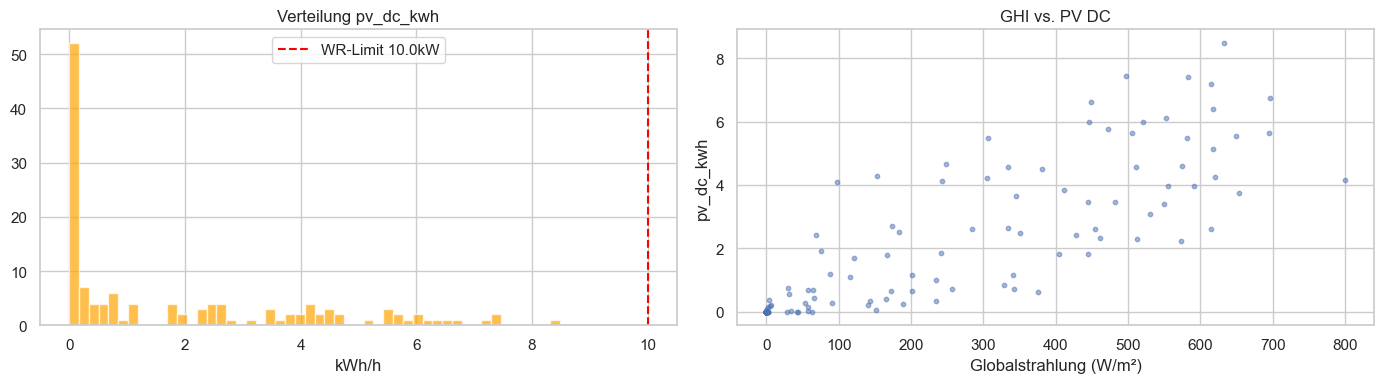

In [3]:
# Wetter laden für den Collector-Zeitraum
from datetime import date, timedelta
weather = get_historical(
    start_date=hourly["timestamp"].min().date(),
    end_date=date.today() - timedelta(days=1),
)
print(f"Wetter: {len(weather)} Stunden")

# Trainingsdatensatz
df = build_training_from_collector(weather, db_path=DB_PATH)
print(f"\nTrainingsdatensatz: {len(df)} Zeilen, {len(df.columns)} Spalten")
print(f"Zeitraum: {df['timestamp'].min()} bis {df['timestamp'].max()}")

# Features prüfen
available = [c for c in FEATURE_COLS if c in df.columns]
missing = [c for c in FEATURE_COLS if c not in df.columns]
print(f"Features: {len(available)} verfügbar, {len(missing)} fehlen")
if missing:
    print(f"  Fehlend: {missing}")

# Target-Verteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df[TARGET_COL], bins=50, color="orange", alpha=0.7, edgecolor="white")
axes[0].set_xlabel("kWh/h")
axes[0].set_title(f"Verteilung {TARGET_COL}")
axes[0].axvline(PV_SPECS["inverter_max_kw"], color="red", linestyle="--", label=f"WR-Limit {PV_SPECS['inverter_max_kw']}kW")
axes[0].legend()

# Korrelation Strahlung vs. PV DC
axes[1].scatter(df["shortwave_radiation"], df[TARGET_COL], alpha=0.5, s=10)
axes[1].set_xlabel("Globalstrahlung (W/m²)")
axes[1].set_ylabel(TARGET_COL)
axes[1].set_title("GHI vs. PV DC")

plt.tight_layout()
plt.show()

## 3. Modelltraining

In [4]:
# Training mit 2 Tagen Test (bei 7 Tagen Daten)
TEST_DAYS = 2

model = PVForecastModel(params={
    "n_estimators": 300,
    "max_depth": 5,
    "learning_rate": 0.05,
    "num_leaves": 16,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "min_child_samples": 10,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42,
    "verbose": -1,
})

metrics = model.train(df, target=TARGET_COL, test_days=TEST_DAYS)

print(f"=== Modell-Performance ({TARGET_COL}) ===")
print(f"Training ({metrics['train_samples']} Samples, ~{metrics['train_samples']//24} Tage):")
print(f"  MAE:  {metrics['train_mae']:.3f} kWh")
print(f"  RMSE: {metrics['train_rmse']:.3f} kWh")
print(f"  R²:   {metrics['train_r2']:.4f}")
print(f"\nTest ({metrics['test_samples']} Samples, {TEST_DAYS} Tage):")
print(f"  MAE:  {metrics['test_mae']:.3f} kWh")
print(f"  RMSE: {metrics['test_rmse']:.3f} kWh")
print(f"  R²:   {metrics['test_r2']:.4f}")
if 'baseline_mae' in metrics:
    improvement = (1 - metrics['test_mae'] / metrics['baseline_mae']) * 100
    print(f"\nBaseline (Persistence, gestern gleiche Stunde):")
    print(f"  MAE:  {metrics['baseline_mae']:.3f} kWh")
    print(f"  Modell vs. Baseline: {improvement:+.1f}%")

=== Modell-Performance (pv_dc_kwh) ===
Training (85 Samples, ~3 Tage):
  MAE:  0.082 kWh
  RMSE: 0.152 kWh
  R²:   0.9963

Test (48 Samples, 2 Tage):
  MAE:  0.552 kWh
  RMSE: 0.836 kWh
  R²:   0.7274

Baseline (Persistence, gestern gleiche Stunde):
  MAE:  0.890 kWh
  Modell vs. Baseline: +38.0%


## 4. Evaluation & Feature Importance

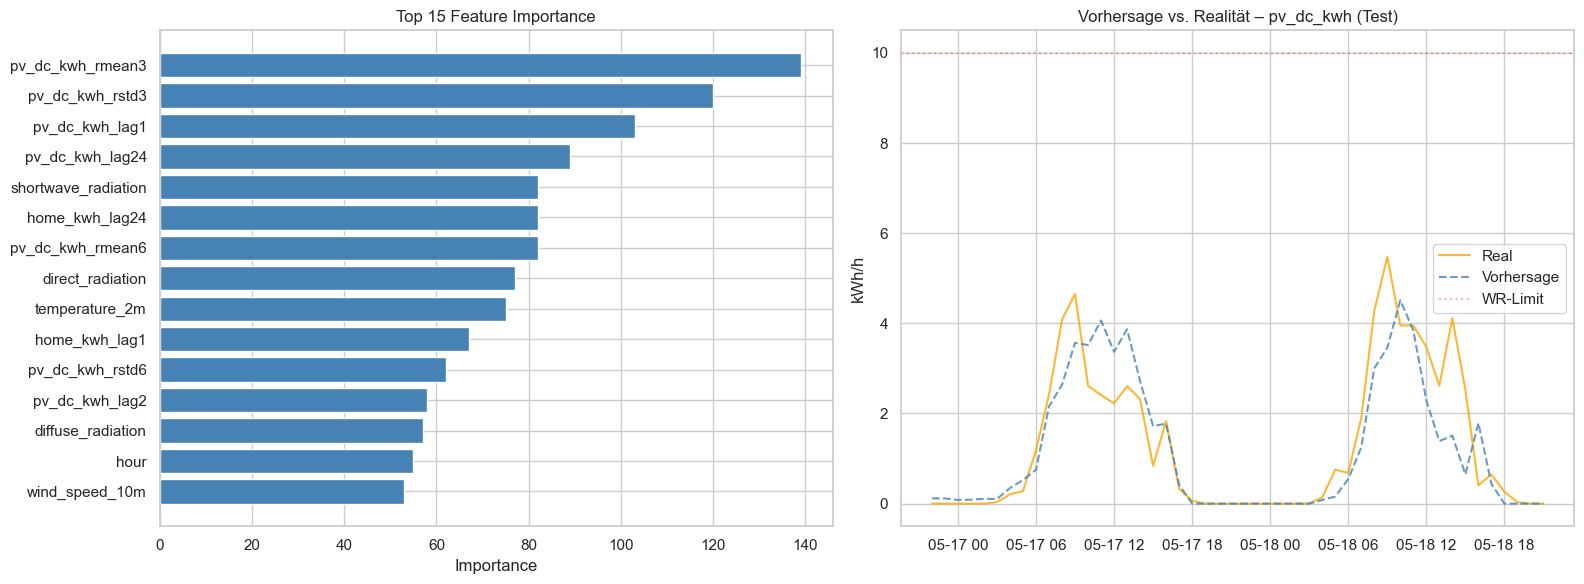

Residuen: mean=0.132, std=0.829
Max Überschätzung: -1.655 kWh
Max Unterschätzung: 2.609 kWh


In [5]:
importance = model.feature_importance()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top Features
top = importance.head(15)
axes[0].barh(top["feature"], top["importance"], color="steelblue")
axes[0].set_xlabel("Importance")
axes[0].set_title("Top 15 Feature Importance")
axes[0].invert_yaxis()

# Vorhersage vs. Realität (Testperiode)
split_date = df["timestamp"].max() - pd.Timedelta(days=TEST_DAYS)
test = df[df["timestamp"] > split_date].copy()
test["predicted"] = model.predict(test)

axes[1].plot(test["timestamp"], test[TARGET_COL], label="Real", alpha=0.8, color="orange")
axes[1].plot(test["timestamp"], test["predicted"], label="Vorhersage", alpha=0.8, linestyle="--", color="steelblue")
axes[1].axhline(PV_SPECS["inverter_max_kw"], color="red", linestyle=":", alpha=0.3, label="WR-Limit")
axes[1].set_ylabel("kWh/h")
axes[1].set_title(f"Vorhersage vs. Realität – {TARGET_COL} (Test)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Residuen-Analyse
test["residual"] = test[TARGET_COL] - test["predicted"]
print(f"Residuen: mean={test['residual'].mean():.3f}, std={test['residual'].std():.3f}")
print(f"Max Überschätzung: {test['residual'].min():.3f} kWh")
print(f"Max Unterschätzung: {test['residual'].max():.3f} kWh")

## 5. Anlagen-Optimierungspotenzial

In [6]:
print("=== Optimierungspotenzial ===")
print()

# 1. WR-Clipping Analyse
dc_total = hourly["pv_dc_kwh"].sum()
ac_total = hourly["pv_kwh"].sum()
clip_loss = dc_total - ac_total
print(f"1. WR-Clipping (Module {PV_SPECS['module_peak_kw']}kWp, WR {PV_SPECS['inverter_max_kw']}kW):")
print(f"   DC-Ertrag: {dc_total:.1f} kWh, AC-Ertrag: {ac_total:.1f} kWh")
print(f"   Verlust durch WR-Begrenzung: {clip_loss:.1f} kWh ({clip_loss/dc_total*100:.1f}%)")
if clip_loss > dc_total * 0.05:
    print(f"   → Signifikant! Größerer WR oder Batterie-Ladung bei Spitzen empfohlen")
else:
    print(f"   → Gering, WR-Dimensionierung passt")

# 2. Batterie voll + Einspeisung
bat_full_export = hourly[(hourly["battery_soc"] >= 98) & (hourly["grid_kwh"] < -0.5)]
export_while_full = abs(bat_full_export["grid_kwh"].sum())
print(f"\n2. Einspeisung bei voller Batterie:")
print(f"   {len(bat_full_export)} Stunden mit Bat≥98% und Einspeisung")
print(f"   Eingespeist: {export_while_full:.1f} kWh (hätte in größerer Batterie gespeichert werden können)")
extra_bat_kwh = min(export_while_full, 10)  # max 10kWh sinnvoll
saved_eur = extra_bat_kwh * (0.2586 - 0.079)  # Differenz Bezug vs. Einspeisung
print(f"   Potenzial bei +{extra_bat_kwh:.0f}kWh Batterie: ~{saved_eur:.1f} EUR/Woche Einsparung")

# 3. Batterie Lade-/Entladeleistung
bat_charge_max = hourly["battery_kwh"].max()
bat_discharge_max = abs(hourly["battery_kwh"].min())
print(f"\n3. Batterie-Leistung:")
print(f"   Max. Ladung: {bat_charge_max:.1f} kWh/h (Limit: {PV_SPECS['battery_max_charge_kw']} kW)")
print(f"   Max. Entladung: {bat_discharge_max:.1f} kWh/h (Limit: {PV_SPECS['battery_max_discharge_kw']} kW)")
if bat_charge_max >= PV_SPECS["battery_max_charge_kw"] * 0.9:
    print(f"   → Ladeleistung wird ausgereizt – höheres Limit könnte helfen")
if bat_discharge_max >= PV_SPECS["battery_max_discharge_kw"] * 0.9:
    print(f"   → Entladeleistung wird ausgereizt – höheres Limit könnte helfen")

=== Optimierungspotenzial ===

1. WR-Clipping (Module 13.4kWp, WR 10.0kW):
   DC-Ertrag: 314.0 kWh, AC-Ertrag: 298.7 kWh
   Verlust durch WR-Begrenzung: 15.3 kWh (4.9%)
   → Gering, WR-Dimensionierung passt

2. Einspeisung bei voller Batterie:
   26 Stunden mit Bat≥98% und Einspeisung
   Eingespeist: 86.7 kWh (hätte in größerer Batterie gespeichert werden können)
   Potenzial bei +10kWh Batterie: ~1.8 EUR/Woche Einsparung

3. Batterie-Leistung:
   Max. Ladung: 4.0 kWh/h (Limit: 5.0 kW)
   Max. Entladung: 2.3 kWh/h (Limit: 5.0 kW)


## 6. Modell speichern

In [ ]:
path = model.save()
size_mb = path.stat().st_size / (1024 * 1024)
print(f"Modell gespeichert: {path}")
print(f"Größe: {size_mb:.2f} MB")
print(f"Pi4-kompatibel: {'✅' if size_mb < 20 else '❌'} (Limit: 20 MB)")
print(f"Target: {TARGET_COL}")
print(f"Test R²: {metrics['test_r2']:.4f}")
print(f"Test MAE: {metrics['test_mae']:.3f} kWh")

Modell gespeichert: d:\GitHub\OptimizePV\notebooks\..\models\pv_forecast.joblib
Größe: 0.22 MB
Pi4-kompatibel: ✅ (Limit: 20 MB)
Target: pv_dc_kwh
Test R²: 0.7274
Test MAE: 0.552 kWh


: 